In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import pickle
from churn_prediction.paths import MODELS_DIR
import warnings
warnings.filterwarnings('ignore')

All directories created successfully!


In [2]:
# 1. Đọc dữ liệu đã xử lý
X_train = np.load(MODELS_DIR / 'X_train.npy')
X_val = np.load(MODELS_DIR / 'X_val.npy')
X_test = np.load(MODELS_DIR / 'X_test.npy')
y_train = np.load(MODELS_DIR / 'y_train.npy')
y_val = np.load(MODELS_DIR / 'y_val.npy')
y_test = np.load(MODELS_DIR / 'y_test.npy')

In [3]:
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Churn rate - Train: {y_train.mean():.2%}, Val: {y_val.mean():.2%}, Test: {y_test.mean():.2%}")

Train: (67353, 30), Val: (14433, 30), Test: (14433, 30)
Churn rate - Train: 89.94%, Val: 89.94%, Test: 89.94%


In [4]:
# 2. Định nghĩa các mô hình
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss')
}

In [5]:
# 3. Huấn luyện và đánh giá các mô hình
results = {}
best_auc = 0
best_model = None
best_name = None

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train, y_train)
    
    # Dự đoán
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Đánh giá
    auc = roc_auc_score(y_test, y_proba)
    results[name] = {
        'model': model,
        'auc': auc,
        'classification_report': classification_report(y_test, y_pred),
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }
    
    print(f"AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred))
    
    if auc > best_auc:
        best_auc = auc
        best_model = model
        best_name = name

print(f"\nBest model: {best_name} with AUC = {best_auc:.4f}")


--- Training Logistic Regression ---
AUC: 0.8520
              precision    recall  f1-score   support

           0       0.65      0.21      0.32      1452
           1       0.92      0.99      0.95     12981

    accuracy                           0.91     14433
   macro avg       0.79      0.60      0.64     14433
weighted avg       0.89      0.91      0.89     14433


--- Training Random Forest ---
AUC: 0.9106
              precision    recall  f1-score   support

           0       0.76      0.48      0.58      1452
           1       0.94      0.98      0.96     12981

    accuracy                           0.93     14433
   macro avg       0.85      0.73      0.77     14433
weighted avg       0.92      0.93      0.92     14433


--- Training Gradient Boosting ---
AUC: 0.9180
              precision    recall  f1-score   support

           0       0.76      0.47      0.58      1452
           1       0.94      0.98      0.96     12981

    accuracy                           0

In [7]:
# 4. Lưu best model
with open(MODELS_DIR / 'best_churn_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(f"Saved best model to 'best_churn_model.pkl'")

Saved best model to 'best_churn_model.pkl'


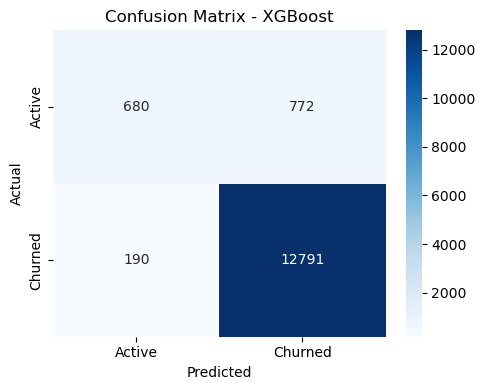

In [8]:
# 5. Vẽ confusion matrix cho best model
cm = results[best_name]['confusion_matrix']
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Active', 'Churned'], 
            yticklabels=['Active', 'Churned'])
plt.title(f'Confusion Matrix - {best_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'confusion_matrix.png')
plt.show()

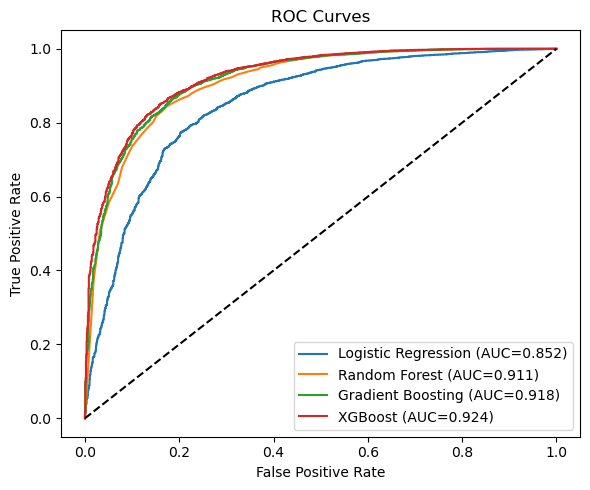

In [9]:
# 6. ROC Curve
plt.figure(figsize=(6,5))
for name, res in results.items():
    model = res['model']
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={res["auc"]:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.tight_layout()
plt.savefig(MODELS_DIR / 'roc_curves.png')
plt.show()

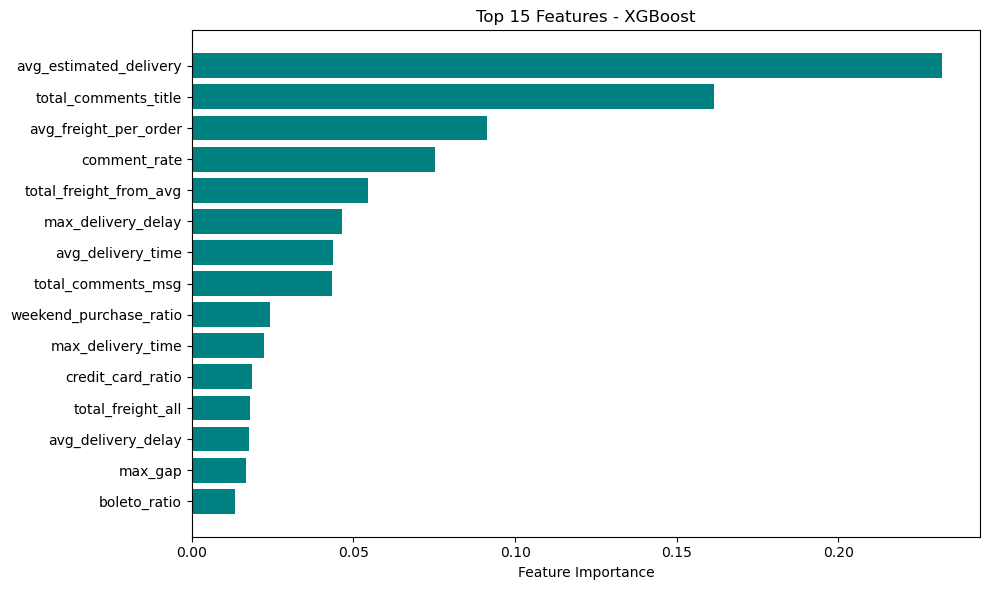


=== MODEL TRAINING HOÀN TẤT ===


In [10]:
# 7. Feature importance (nếu có)
if hasattr(best_model, 'feature_importances_'):
    # Đọc tên features đã chọn
    with open(MODELS_DIR / 'feature_selector.pkl', 'rb') as f:
        selector = pickle.load(f)
    selected_features = selector.get_feature_names_out()
    
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1][:15]  # top 15
    
    plt.figure(figsize=(10,6))
    plt.barh(range(len(indices)), importances[indices], color='teal')
    plt.yticks(range(len(indices)), [selected_features[i] for i in indices])
    plt.xlabel('Feature Importance')
    plt.title(f'Top 15 Features - {best_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(MODELS_DIR / 'feature_importance.png')
    plt.show()

print("\n=== MODEL TRAINING HOÀN TẤT ===")